In [1]:
install.packages("haven")
library(haven)

cars_df <- read_sas("/workspaces/myfolder/mydata/filtered_cars.sas7bdat")

# Preview
head(cars_df)


Installing package into ‘/workspaces/myfolder/.user-R-packages’
(as ‘lib’ is unspecified)



Make,Model,Type,Origin,DriveTrain,MSRP,Horsepower,MPG_City
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Acura,MDX,SUV,Asia,All,36945,265,17
BMW,X3 3.0i,SUV,Europe,All,37000,225,16
Buick,Rainier,SUV,USA,All,37895,275,15
Buick,Rendezvous CX,SUV,USA,Front,26545,185,19
Chevrolet,TrailBlazer LT,SUV,USA,Front,30295,275,16
Chevrolet,Tracker,SUV,USA,Front,20255,165,19


In [2]:
library(knitr)
library(dplyr)

summary_table <- cars_df %>%
  group_by(DriveTrain) %>%
  summarise(
    Count = n(),
    Avg_MPG_City = round(mean(MPG_City, na.rm = TRUE), 1),
    Avg_Horsepower = round(mean(Horsepower, na.rm = TRUE), 1),
    Avg_MSRP = round(mean(MSRP, na.rm = TRUE), 0)
  )

# Display table
kable(summary_table, caption = "Summary by Drivetrain")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union






Table: Summary by Drivetrain

|DriveTrain | Count| Avg_MPG_City| Avg_Horsepower| Avg_MSRP|
|:----------|-----:|------------:|--------------:|--------:|
|All        |    24|         17.4|          205.0|    28591|
|Front      |    18|         17.1|          215.6|    26270|

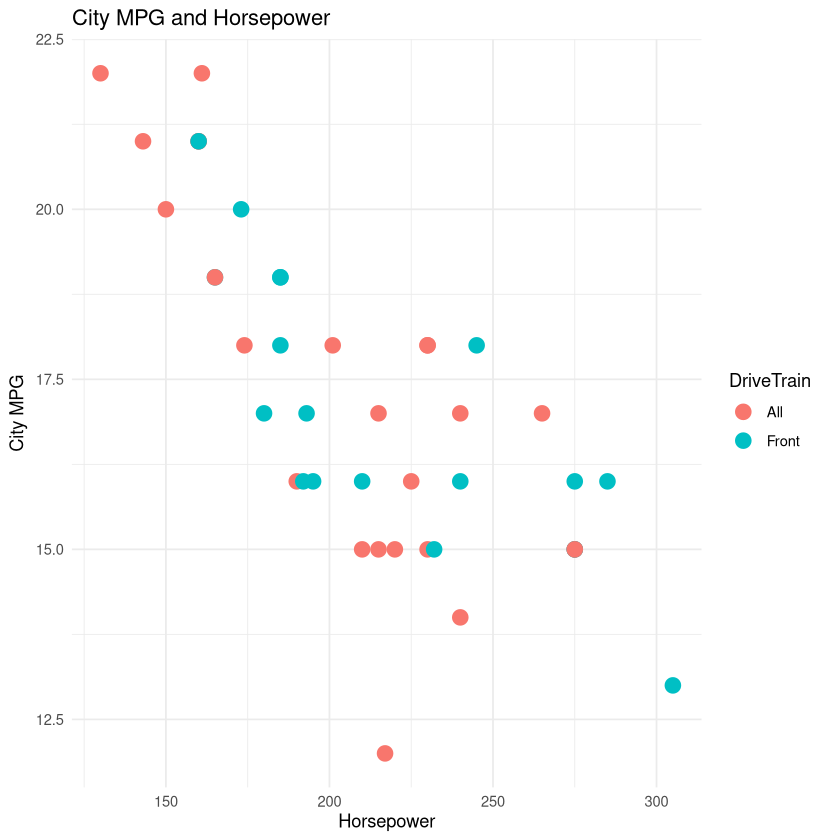

In [3]:
library(ggplot2)

ggplot(cars_df, aes(
  x = Horsepower,
  y = MPG_City,
  color = DriveTrain,
  text = paste(
    "Make:", Make,
    "Model:", Model,
    "MPG:", MPG_City,
    "HP:", Horsepower
  )
)) +
  geom_point(size = 4) +
  labs(
    title = "City MPG and Horsepower",
    x = "Horsepower",
    y = "City MPG",
    color = "DriveTrain"
  ) +
  theme_minimal()
